In [37]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
import imutils

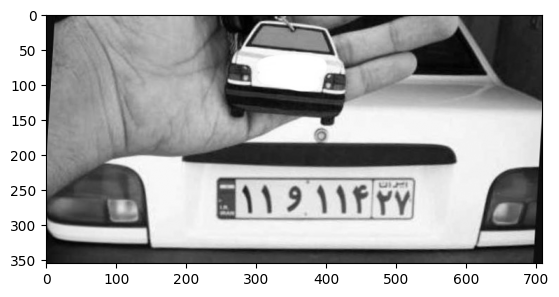

In [38]:
car_img = cv.imread('images/Car_plate2.jpg')
car_img_gray = cv.cvtColor(car_img, cv.COLOR_BGR2GRAY)
plt.imshow(car_img_gray, cmap='gray')

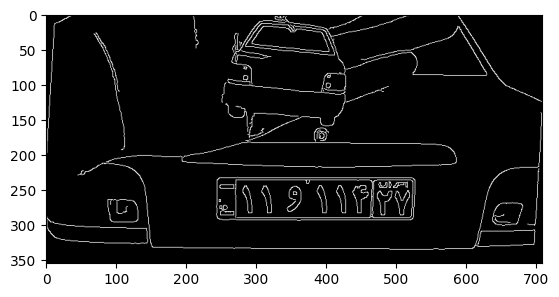

In [39]:
bilateral_filtered = cv.bilateralFilter(car_img_gray, 30, 15, 15)
edges = cv.Canny(bilateral_filtered, 30, 200)
plt.imshow(edges, cmap='gray')

In [40]:
contours = cv.findContours(edges.copy(), cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
contours_refined = imutils.grab_contours(contours)
contours_sorted = sorted(contours_refined, key=cv.contourArea, reverse=True)[:4]

In [41]:
for contour in contours_sorted:
    contour_approx = cv.approxPolyDP(contour, 20, True)
    if len(contour_approx) == 4:
        plate_location = contour_approx
        break

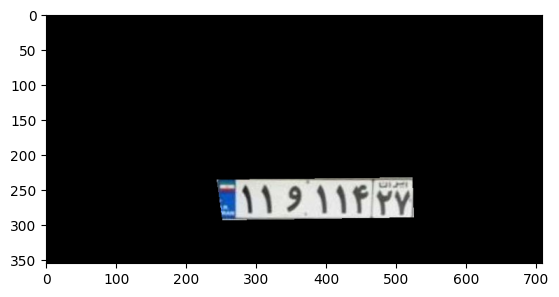

In [42]:
plate_mask0 = np.zeros(car_img_gray.shape, np.uint8)
plate_mask1 = cv.drawContours(plate_mask0, [plate_location], 0, 255, -1)
plate_img = cv.bitwise_and(car_img, car_img, mask=plate_mask1)
plt.imshow(plate_img[...,::-1])

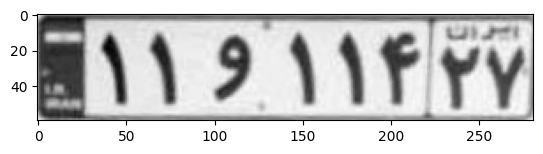

In [43]:
(x, y) = np.where(plate_mask1 == 255)
(x1, y1) = (np.min(x), np.min(y))
(x2, y2) = (np.max(x), np.max(y))
cropped_image = car_img_gray[x1:x2, y1:y2]
plt.imshow(cropped_image, cmap='gray')


## Converting Plate Image To Plate Text

In [44]:
import easyocr

In [47]:
reader = easyocr.Reader(["en", "fa"])
plate_info = reader.readtext(cropped_image)
print(plate_info)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[[[[27, 1], [281, 1], [281, 60], [27, 60]], '١١ 9 ١١٤٢٧', 0.6817057334759402]]


In [48]:
plate_text = plate_info[0][-2]
plate_text

'١١ 9 ١١٤٢٧'